In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/nishi1195/applysmart/final_encoded_dataset.csv


In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf

from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tensorflow.keras import regularizers

2026-03-16 15:30:47.445826: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773675047.628247      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773675047.677042      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773675048.092382      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773675048.092422      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773675048.092425      55 computation_placer.cc:177] computation placer alr

In [3]:
df = pd.read_csv("/kaggle/input/datasets/nishi1195/applysmart/final_encoded_dataset.csv")
df.head()

,resume_text,job_description,decision
0,Here's a professional resume for Jason Jones:\...,Be part of a passionate team at the forefront ...,0
1,Here's a professional resume for Ann Marshall:...,Help us build the next-generation products as ...,1
2,Here's a professional resume for Patrick Mccla...,We need a Human Resources Specialist to enhanc...,0
3,Here's a professional resume for Patricia Gray...,Be part of a passionate team at the forefront ...,1
4,Here's a professional resume for Amanda Gross:...,We are looking for an experienced E-commerce S...,0


In [4]:
print(df.shape)
print(df.info())

(20174, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20174 entries, 0 to 20173
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   resume_text      20174 non-null  object
 1   job_description  20174 non-null  object
 2   decision         20174 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 473.0+ KB
None


In [5]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"\S+@\S+", "", text)
    text = re.sub(r"\+?\d[\d -]{8,}\d", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["resume_text"] = df["resume_text"].apply(clean_text)
df["job_description"] = df["job_description"].apply(clean_text)

In [6]:
resumes = df["resume_text"].tolist()
jds = df["job_description"].tolist()
labels = df["decision"].values

In [7]:
import random

# Create Positive Pairs
positive_pairs = [(resumes[i], jds[i], 1) for i in range(len(resumes))]

# Create Negative Pairs
negative_pairs = []

for i in range(len(resumes)):
    
    # choose a random JD that is NOT the correct one
    j = random.randint(0, len(jds)-1)
    
    while j == i:
        j = random.randint(0, len(jds)-1)
        
    negative_pairs.append((resumes[i], jds[j], 0))


# Combine Dataset
pairs = positive_pairs + negative_pairs
random.shuffle(pairs)

resumes_new = [p[0] for p in pairs]
jds_new = [p[1] for p in pairs]
labels_new = np.array([p[2] for p in pairs])

print("Total training pairs:", len(labels_new))

Total training pairs: 40348


In [8]:
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [9]:
resume_embeddings = embedding_model.encode(
    resumes_new,
    convert_to_numpy=True,
    show_progress_bar=True
)
print("Resume Embedding Shape:", resume_embeddings.shape)

jd_embeddings = embedding_model.encode(
    jds_new,
    convert_to_numpy=True,
    show_progress_bar=True
)
print("JD Embedding Shape:", jd_embeddings.shape)

Batches:   0%|          | 0/1261 [00:00<?, ?it/s]

Resume Embedding Shape: (40348, 384)


Batches:   0%|          | 0/1261 [00:00<?, ?it/s]

JD Embedding Shape: (40348, 384)


In [10]:
# Cosine similarity
from sklearn.metrics.pairwise import cosine_similarity

cos_sim = cosine_similarity(resume_embeddings, jd_embeddings).diagonal()

In [11]:
# Feature matrix
features = np.concatenate([
    resume_embeddings,
    jd_embeddings,
    np.abs(resume_embeddings - jd_embeddings),
    resume_embeddings * jd_embeddings,
    cos_sim.reshape(-1,1)
], axis=1)

print("Feature Shape:", features.shape)

Feature Shape: (40348, 1537)


In [12]:
# Normalize feature
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

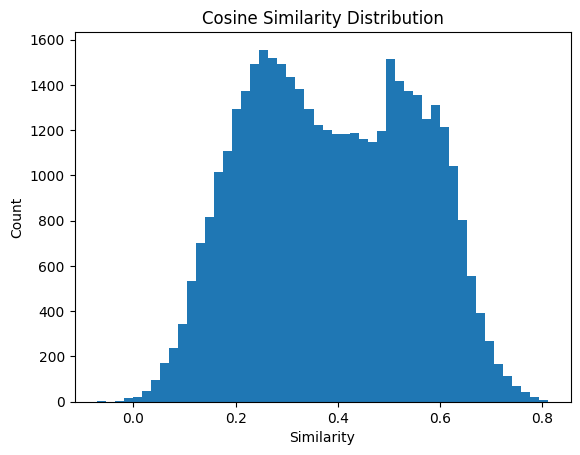

In [13]:
import matplotlib.pyplot as plt

plt.hist(cos_sim, bins=50)
plt.title("Cosine Similarity Distribution")
plt.xlabel("Similarity")
plt.ylabel("Count")
plt.show()

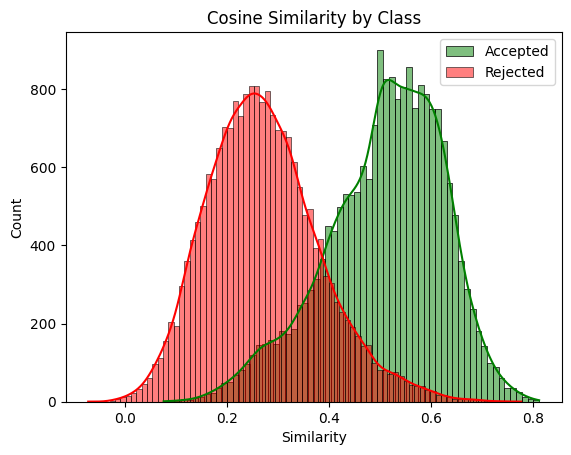

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()

sns.histplot(cos_sim[labels_new==1], color="green", label="Accepted", kde=True)
sns.histplot(cos_sim[labels_new==0], color="red", label="Rejected", kde=True)

plt.legend()
plt.title("Cosine Similarity by Class")
plt.xlabel("Similarity")
plt.ylabel("Count")

plt.show()

In [18]:
# Checing for class imbalance

print("Accepted:", np.sum(labels_new==1))
print("Rejected:", np.sum(labels_new==0))

Accepted: 20174
Rejected: 20174


In [19]:
# Train-Test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features_scaled,
    labels_new,
    test_size=0.2,
    random_state=42
)

In [21]:
# Base model

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Baseline Accuracy:", accuracy_score(y_test, pred))

Baseline Accuracy: 0.9531598513011152


In [22]:
from sklearn.utils import shuffle
X_train,y_train = shuffle(X_train, y_train, random_state=42)

In [23]:
from tensorflow.keras import layers, models, regularizers

input_dim = X_train.shape[1]

model = models.Sequential([

    layers.Input(shape=(input_dim,)),

    layers.Dense(512, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    layers.Dense(256, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(32, activation='relu'),
    
    layers.Dense(1, activation='sigmoid')
])

model.summary()

I0000 00:00:1773676437.474212      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15155 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       787,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 959,425 (3.66 MB)

 Trainable params: 957,633 (3.65 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [24]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)

In [25]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

In [27]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/50
908/908 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9483 - auc: 0.9809 - loss: 0.5353 - val_accuracy: 0.9659 - val_auc: 0.9869 - val_loss: 0.3433 - learning_rate: 0.0010
Epoch 2/50
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9465 - auc: 0.9817 - loss: 0.3698 - val_accuracy: 0.9507 - val_auc: 0.9841 - val_loss: 0.3471 - learning_rate: 0.0010
Epoch 3/50
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9449 - auc: 0.9799 - loss: 0.3609 - val_accuracy: 0.9613 - val_auc: 0.9858 - val_loss: 0.3198 - learning_rate: 0.0010
Epoch 4/50
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9452 - auc: 0.9804 - loss: 0.3447 - val_accuracy: 0.9538 - val_auc: 0.9845 - val_loss: 0.3259 - learning_rate: 0.0010
Epoch 5/50
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9479 - auc: 0.9797 - loss: 0.3426 - val_accuracy: 0.9569 - val_auc: 0.9852 - val_loss: 0.3185 - learning_rate: 0.0010
Epoch 6/50
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9469 - auc: 0.

In [29]:
test_loss, test_acc, test_auc = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)
print("Test AUC:", test_auc)

253/253 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9765 - auc: 0.9909 - loss: 0.1185
Test Loss: 0.11810223013162613
Test Accuracy: 0.975836455821991
Test AUC: 0.9905416369438171


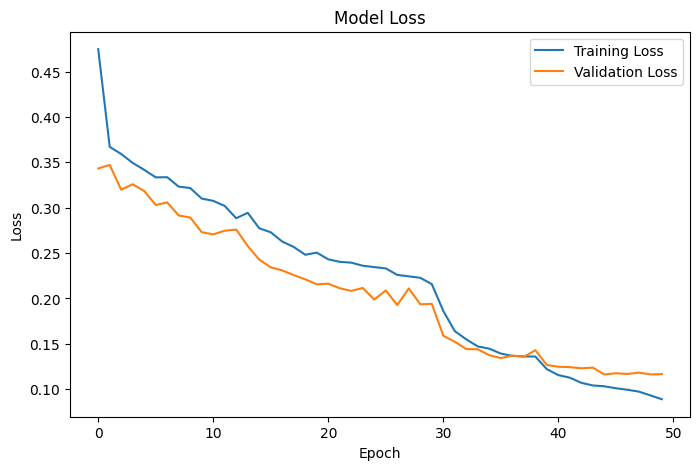

In [30]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

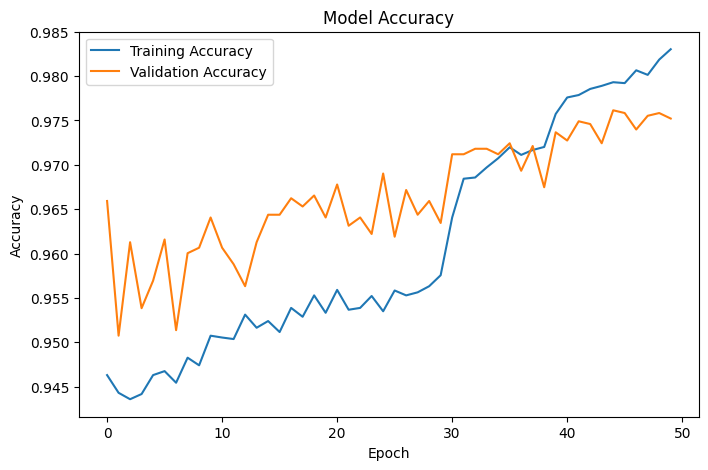

In [31]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

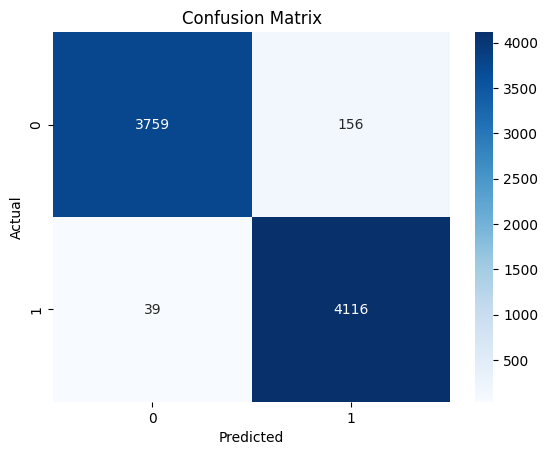

              precision    recall  f1-score   support

           0       0.99      0.96      0.97      3915
           1       0.96      0.99      0.98      4155

    accuracy                           0.98      8070
   macro avg       0.98      0.98      0.98      8070
weighted avg       0.98      0.98      0.98      8070



In [33]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(y_test, pred_class)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

print(classification_report(y_test, pred_class))

In [34]:
model.save("resume_match_model.h5")

In [35]:
import joblib
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']